# Sylph viral-database comparison

Compare **UHVDB**, **Phanta** (`votus_hq_plus`), **BAQLaVa** (dereplicated), and **Marker-MAGu** (TGVG) when each is used as the viral reference for sylph profiling of simulated non-fragment reads (splits 1–17).

Metrics (RBH linking, matching `uhvdb_sylph_coverage_correlations.ipynb`):
- **Pearson r**: simulated `coverage` vs sylph `True_cov` for RBH pairs with `True_cov > 0.1`
- **Recall**: `# inputs with RBH detection (True_cov > 0.1) / # input genomes`

Profiles: viral `.syldb` + GTDB r226 (`*_gtdb226.profile.tsv`). Data root: `../figure_4/virome_profiling/`

Precomputed outputs (from the same RBH logic): `sylph_database_comparison_metrics.tsv`, `sylph_database_comparison.png`, `sylph_database_comparison_by_site.png`.

| Database | Recall | Pearson r |
|----------|--------|-----------|
| UHVDB | 0.818 | 0.962 |
| Marker-MAGu (TGVG) | 0.688 | 0.933 |
| Phanta | 0.578 | 0.945 |
| BAQLaVa | 0.466 | 0.953 |

In [27]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from scipy.stats import pearsonr

DATA = Path('../figure_4/virome_profiling')
READSIM = DATA / 'readsim'
SPLITS = range(1, 18)
DETECT_THRESH = 0.1
PLOT_FLOOR = 0.1

# database_label -> (anicalc path, sylph profile dir, profile filename stem)
DBS = {
    'UHVDB': (
        DATA / 'uhvdb_v4_blast' / 'combined_renamed_v_uhvdb4.anicalc.tsv',
        DATA / 'uhvdb_v4_sylph_profile',
        'uhvdb4_gtdb226',
    ),
    'Phanta': (
        DATA / 'uhvdb_phanta' / 'combined_renamed_v_votus_hq_plus.anicalc.tsv',
        DATA / 'phanta_sylph_profile',
        'phanta_gtdb226',
    ),
    'BAQLaVa': (
        DATA / 'uhvdb_baqlava' / 'combined_renamed_v_baqlava_derep.anicalc.tsv',
        DATA / 'baqlava_sylph_profile',
        'baqlava_gtdb226',
    ),
    'Marker-MAGu': (
        DATA / 'uhvdb_markermagu' / 'combined_renamed_v_tgvg.anicalc.tsv',
        DATA / 'tgvg_sylph_profile',
        'tgvg_gtdb226',
    ),
}

DB_ORDER = ['UHVDB', 'Phanta', 'BAQLaVa', 'Marker-MAGu']
SITE_ORDER = ['gut', 'oral', 'skin', 'urogenital']

sns.set(style='whitegrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})


def body_site_for_split(i: int) -> str:
    if i <= 10:
        return 'gut'
    if i < 15:
        return 'oral'
    if i < 17:
        return 'skin'
    return 'urogenital'


def safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 3:
        return np.nan, len(x)
    r, _ = pearsonr(x, y)
    return float(r), len(x)


def profile_path(sylph_dir: Path, split: int, stem: str) -> Path:
    return sylph_dir / f'split_{split}' / f'split_{split}_{stem}.profile.tsv'


print('DATA =', DATA.resolve())
for label, (ani, sdir, stem) in DBS.items():
    n_ready = sum(1 for i in SPLITS if profile_path(sdir, i, stem).is_file())
    print(f'{label}: anicalc={ani.exists()} profiles={n_ready}/17 ({sdir.name})')

DATA = /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_4/virome_profiling
UHVDB: anicalc=True profiles=17/17 (uhvdb_v4_sylph_profile)
Phanta: anicalc=True profiles=17/17 (phanta_sylph_profile)
BAQLaVa: anicalc=True profiles=17/17 (baqlava_sylph_profile)
Marker-MAGu: anicalc=True profiles=17/17 (tgvg_sylph_profile)


## Build RBH-linked tables per database

For each split and database:
1. Filter sylph hits to `Adjusted_ANI >= 95`
2. Link to inputs via anicalc (`match_qani`, `match_tani`)
3. Keep reciprocal best hits only
4. Left-join onto all input genomes

In [28]:
def build_rbh_table(anicalc_path: Path, sylph_dir: Path, stem: str) -> pl.DataFrame:
    anicalc = pl.read_csv(anicalc_path, separator='\t')
    rows = []

    for i in SPLITS:
        site = body_site_for_split(i)
        prof = profile_path(sylph_dir, i, stem)
        if not prof.is_file():
            raise FileNotFoundError(f'Missing sylph profile: {prof}')

        input_genomes = (
            pl.read_csv(READSIM / f'split_{i}_reads_cov.txt', separator='\t')
            .rename({'tname': 'qname'})
            .select(['qname', 'genome_length', 'read_count', 'coverage'])
        )
        input_ids = set(input_genomes['qname'].to_list())

        qani_global = (
            anicalc
            .filter(pl.col('qname').is_in(input_ids))
            .with_columns(((pl.col('pid') * pl.col('qcov')) / 10000).alias('qani'))
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True)
            .select(['qname', 'qani'])
        )

        sylph = (
            pl.read_csv(prof, separator='\t', ignore_errors=True)
            .with_columns(pl.col('Contig_name').str.split(' ').list.first().alias('contig_id'))
            .filter(pl.col('Adjusted_ANI') >= 95)
            .select(['contig_id', 'True_cov', 'Adjusted_ANI'])
        )
        detected_ids = set(sylph['contig_id'].to_list())

        links = (
            anicalc
            .filter(pl.col('qname').is_in(input_ids) & pl.col('tname').is_in(detected_ids))
            .with_columns([
                ((pl.col('pid') * pl.col('qcov')) / 10000).alias('match_qani'),
                ((pl.col('pid') * pl.col('tcov')) / 10000).alias('match_tani'),
            ])
            .select(['qname', pl.col('tname').alias('contig_id'), 'match_qani', 'match_tani'])
        )

        best_for_input = links.sort('match_qani', descending=True).unique('qname', maintain_order=True)
        best_for_contig = (
            links
            .sort('match_tani', descending=True)
            .unique('contig_id', maintain_order=True)
            .select(['qname', 'contig_id'])
        )

        rbh = (
            best_for_input
            .join(best_for_contig, on=['qname', 'contig_id'], how='inner')
            .join(sylph, on='contig_id', how='left')
        )

        rows.append(
            input_genomes
            .join(qani_global, on='qname', how='left')
            .with_columns(pl.col('qani').fill_null(0.0))
            .join(rbh, on='qname', how='left')
            .with_columns([
                pl.lit(i).alias('split'),
                pl.lit(site).alias('body_site'),
                pl.col('contig_id').is_not_null().alias('has_rbh'),
            ])
        )

    return pl.concat(rows, how='diagonal_relaxed')


rbh_by_db = {}
for label in DB_ORDER:
    ani, sdir, stem = DBS[label]
    n_ready = sum(1 for i in SPLITS if profile_path(sdir, i, stem).is_file())
    if n_ready < 17:
        print(f'SKIP {label}: only {n_ready}/17 profiles ready')
        continue
    print(f'Building RBH table for {label} ...')
    df = build_rbh_table(ani, sdir, stem)
    rbh_by_db[label] = df
    n_det = df.filter(pl.col('True_cov') > DETECT_THRESH).height
    print(f'  inputs={df.height}, RBH={df.filter(pl.col("has_rbh")).height}, detected={n_det}')

print('Loaded databases:', list(rbh_by_db.keys()))

Building RBH table for UHVDB ...
  inputs=1700, RBH=1390, detected=1390
Building RBH table for Phanta ...
  inputs=1700, RBH=983, detected=983
Building RBH table for BAQLaVa ...
  inputs=1700, RBH=793, detected=793
Building RBH table for Marker-MAGu ...
  inputs=1700, RBH=1170, detected=1169
Loaded databases: ['UHVDB', 'Phanta', 'BAQLaVa', 'Marker-MAGu']


## Pearson r and recall summary

In [29]:
def summarize_metrics(df: pl.DataFrame, database: str, body_site=None) -> dict:
    sub = df if body_site is None else df.filter(pl.col('body_site') == body_site)
    n_total = sub.height
    det = sub.filter(pl.col('True_cov') > DETECT_THRESH)
    n_det = det.height
    r, n_r = safe_pearson(det['coverage'].to_list(), det['True_cov'].to_list())
    return {
        'database': database,
        'body_site': 'all' if body_site is None else body_site,
        'n_total': n_total,
        'n_detected': n_det,
        'recall': n_det / n_total if n_total else np.nan,
        'pearson_r': r,
        'n_pearson': n_r,
    }


metric_rows = []
for label, df in rbh_by_db.items():
    metric_rows.append(summarize_metrics(df, label, None))
    for site in SITE_ORDER:
        metric_rows.append(summarize_metrics(df, label, site))

metrics = pd.DataFrame(metric_rows)
metrics['database'] = pd.Categorical(metrics['database'], categories=DB_ORDER, ordered=True)
metrics['body_site'] = pd.Categorical(
    metrics['body_site'], categories=['all'] + SITE_ORDER, ordered=True
)
metrics = metrics.sort_values(['body_site', 'database']).reset_index(drop=True)

overall = metrics.query('body_site == "all"').copy()
display(overall)
display(metrics.query('body_site != "all"'))

,database,body_site,n_total,n_detected,recall,pearson_r,n_pearson
0,UHVDB,all,1700,1390,0.817647,0.962067,1390
1,Phanta,all,1700,983,0.578235,0.944630,983
2,BAQLaVa,all,1700,793,0.466471,0.953490,793
3,Marker-MAGu,all,1700,1169,0.687647,0.933302,1169


,database,body_site,n_total,n_detected,recall,pearson_r,n_pearson
4,UHVDB,gut,1000,845,0.8450,0.972374,845
5,Phanta,gut,1000,789,0.7890,0.967264,789
6,BAQLaVa,gut,1000,619,0.6190,0.960248,619
7,Marker-MAGu,gut,1000,808,0.8080,0.964329,808
8,UHVDB,oral,400,323,0.8075,0.979443,323
9,Phanta,oral,400,141,0.3525,0.980043,141
10,BAQLaVa,oral,400,102,0.2550,0.931929,102
11,Marker-MAGu,oral,400,270,0.6750,0.958531,270
12,UHVDB,skin,200,142,0.7100,0.921641,142
13,Phanta,skin,200,31,0.1550,0.981613,31


## Comparison plot — Pearson r and recall vs UHVDB+sylph

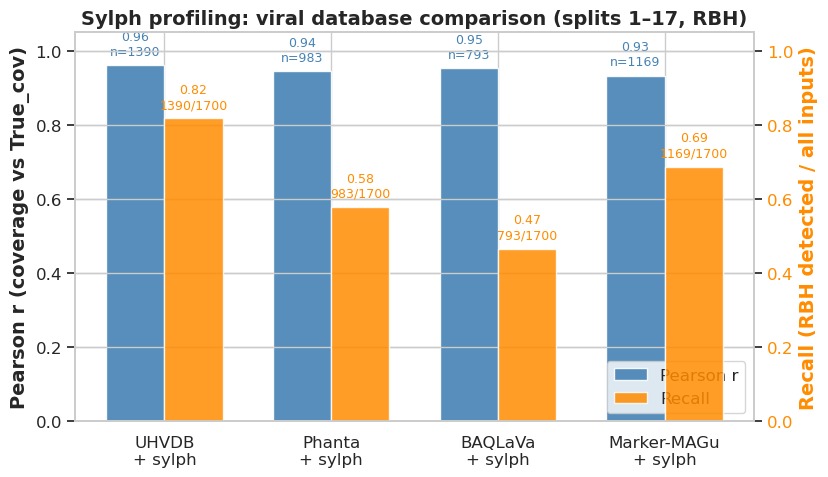

In [30]:
plot_df = overall.copy()
x = np.arange(len(plot_df))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8.5, 5))
bars_r = ax1.bar(x - width / 2, plot_df['pearson_r'], width=width, color='steelblue', alpha=0.9, label='Pearson r')
ax1.set_ylabel('Pearson r (coverage vs True_cov)')
ax1.set_ylim(0, 1.05)
ax1.set_xticks(x)
ax1.set_xticklabels([f'{d}\n+ sylph' for d in plot_df['database']])

ax2 = ax1.twinx()
bars_rec = ax2.bar(x + width / 2, plot_df['recall'], width=width, color='darkorange', alpha=0.85, label='Recall')
ax2.set_ylabel('Recall (RBH detected / all inputs)', color='darkorange')
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='y', labelcolor='darkorange')

for bar, r, n in zip(bars_r, plot_df['pearson_r'], plot_df['n_pearson']):
    if np.isfinite(r):
        ax1.text(bar.get_x() + bar.get_width() / 2, r + 0.02, f'{r:.2f}\nn={n}',
                 ha='center', va='bottom', fontsize=9, color='steelblue')

for bar, rec, nd, nt in zip(bars_rec, plot_df['recall'], plot_df['n_detected'], plot_df['n_total']):
    if np.isfinite(rec):
        ax2.text(bar.get_x() + bar.get_width() / 2, rec + 0.02, f'{rec:.2f}\n{nd}/{nt}',
                 ha='center', va='bottom', fontsize=9, color='darkorange')

handles = [bars_r, bars_rec]
labels = ['Pearson r', 'Recall']
ax1.legend(handles, labels, loc='lower right')
ax1.set_title('Sylph profiling: viral database comparison (splits 1–17, RBH)')
plt.tight_layout()
plt.show()

## Body-site breakdown

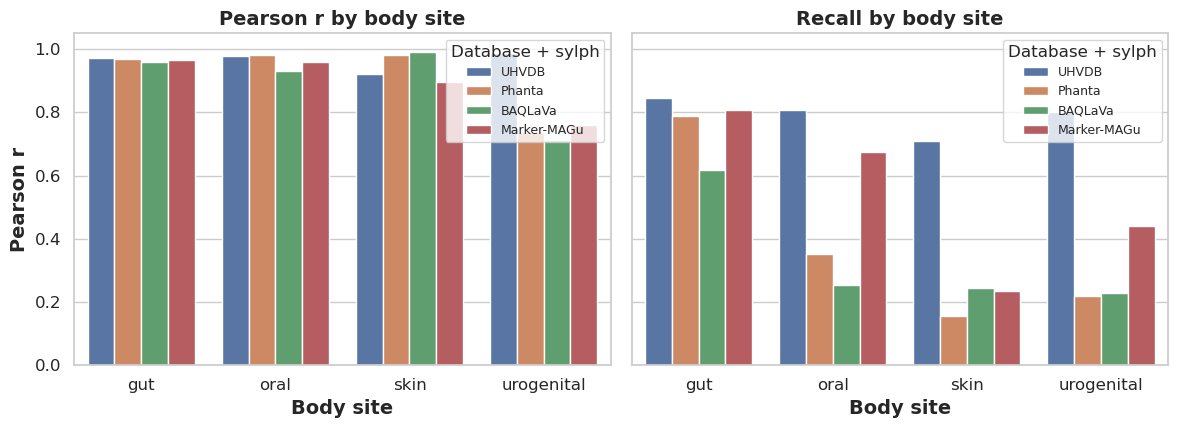

In [31]:
by_site = metrics.query('body_site != "all"').copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

sns.barplot(
    data=by_site, x='body_site', y='pearson_r', hue='database',
    hue_order=DB_ORDER, order=SITE_ORDER, ax=axes[0],
)
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel('Body site')
axes[0].set_ylabel('Pearson r')
axes[0].set_title('Pearson r by body site')
axes[0].legend(title='Database + sylph', fontsize=9)

sns.barplot(
    data=by_site, x='body_site', y='recall', hue='database',
    hue_order=DB_ORDER, order=SITE_ORDER, ax=axes[1],
)
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('Body site')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall by body site')
axes[1].legend(title='Database + sylph', fontsize=9)

plt.tight_layout()
plt.show()

## Per-database coverage scatter (figure_4b style)


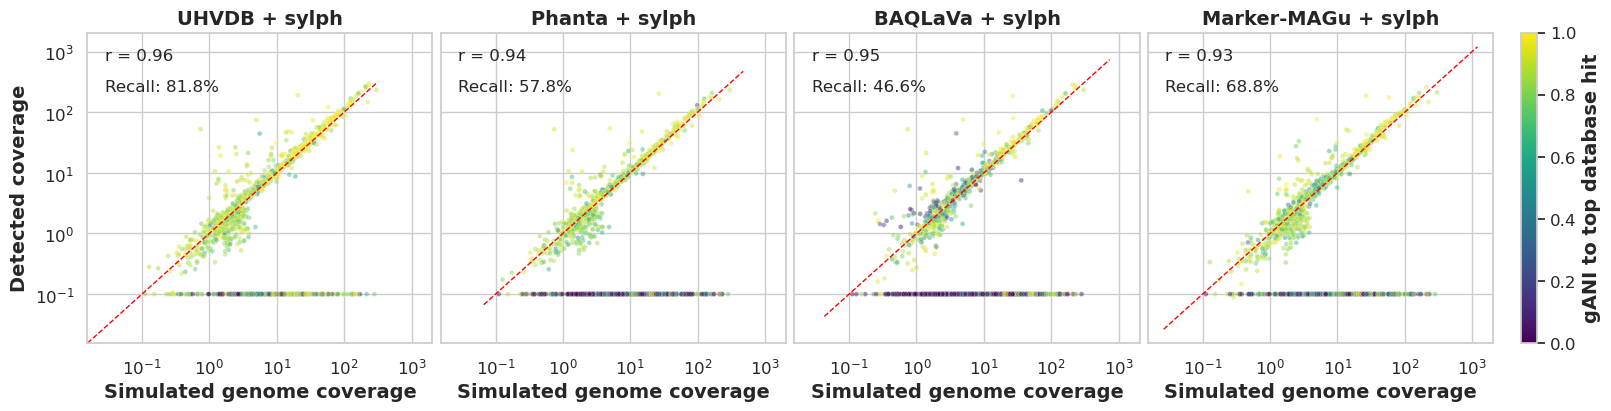

In [32]:
# Match figure_4b combined-panel style: viridis gANI hue, shared colorbar, 1:1 line
labels = [d for d in DB_ORDER if d in rbh_by_db]
n_dbs = len(labels)
if n_dbs == 0:
    print('No databases ready yet')
else:
    fig, axes = plt.subplots(
        1, n_dbs, figsize=(4 * n_dbs, 4), sharex=True, sharey=True, constrained_layout=True,
    )
    if n_dbs == 1:
        axes = [axes]

    for ax, label in zip(axes, labels):
        tdf = (
            rbh_by_db[label]
            .with_columns(
                pl.when(pl.col('True_cov').is_null() | (pl.col('True_cov') <= 0))
                .then(pl.lit(PLOT_FLOOR))
                .otherwise(pl.col('True_cov'))
                .alias('Detected coverage')
            )
            .rename({'coverage': 'Simulated genome coverage'})
        )

        sns.scatterplot(
            data=tdf.to_pandas(),
            x='Simulated genome coverage',
            y='Detected coverage',
            s=12,
            alpha=0.45,
            hue='qani',
            palette='viridis',
            hue_norm=(0, 1),
            ax=ax,
            legend=False,
        )
        lims = [
            min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1]),
        ]
        ax.plot(lims, lims, '--', color='red', linewidth=1)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'{label} + sylph', fontsize=14)
        ax.set_xlabel('Simulated genome coverage', fontsize=14)
        ax.set_ylabel('Detected coverage' if ax is axes[0] else '', fontsize=14)

        det = tdf.filter(pl.col('Detected coverage') > DETECT_THRESH)
        r = (
            pearsonr(
                det['Simulated genome coverage'].to_list(),
                det['Detected coverage'].to_list(),
            )[0]
            if det.height >= 2
            else float('nan')
        )
        tp = det.unique('qname').height
        total = tdf.unique('qname').height
        recovery = tp / total * 100 if total else 0
        ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
        ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=12, verticalalignment='top')

    norm = mcolors.Normalize(vmin=0, vmax=1)
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02, label='gANI to top database hit')
    plt.show()
